# TerraMind Inference and Visualization
Load trained model, make predictions on Sen1Floods11 samples, and visualize results with RGB composites and ground truth overlay.

## 1. Import Required Libraries

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import logging
import argparse
from pathlib import Path
from typing import Dict, Any, Tuple
import warnings
warnings.filterwarnings('ignore')

from terratorch.tasks import SemanticSegmentationTask
from terratorch import BACKBONE_REGISTRY
from terratorch.datamodules.sen1floods11 import Sen1Floods11NonGeoDataModule

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import WandbLogger

from terra_sat_drift.data_simulation.phisat2_constants import S2_BANDS_NAMES, S2_BANDS, S2_PAN_BANDS


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
root_dir="/shared/home/elucas/datasets/sen1floods11"

datamodule = Sen1Floods11NonGeoDataModule(
    batch_size=8,
    data_root=root_dir,
    bands=S2_BANDS_NAMES,
    num_workers=4,
    download=False,
    use_metadata=True,
    rgb_indices=[3, 2, 1],
    num_classes=2,
)

In [3]:
datamodule.setup(stage="validate")
val_dataset = datamodule.val_dataset

print(f"Available samples in the training dataset: {len(val_dataset)}")
print(f"Input shape of first sample: {val_dataset[0]['image'].shape}")

Available samples in the training dataset: 89
Input shape of first sample: torch.Size([7, 512, 512])


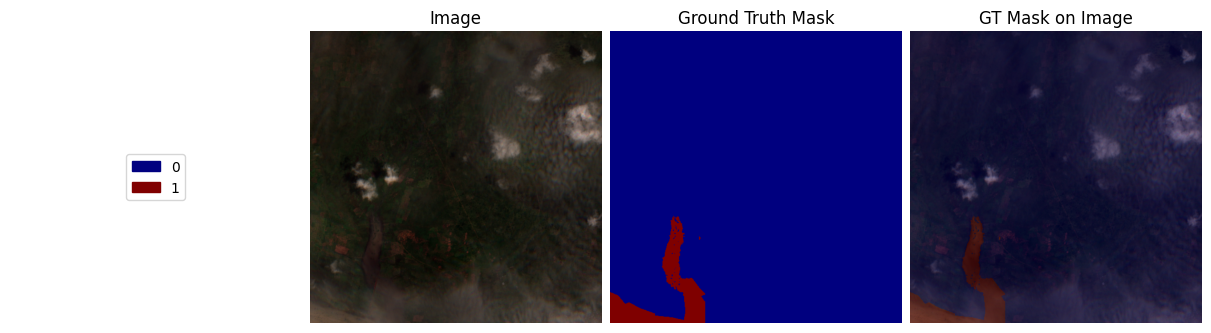

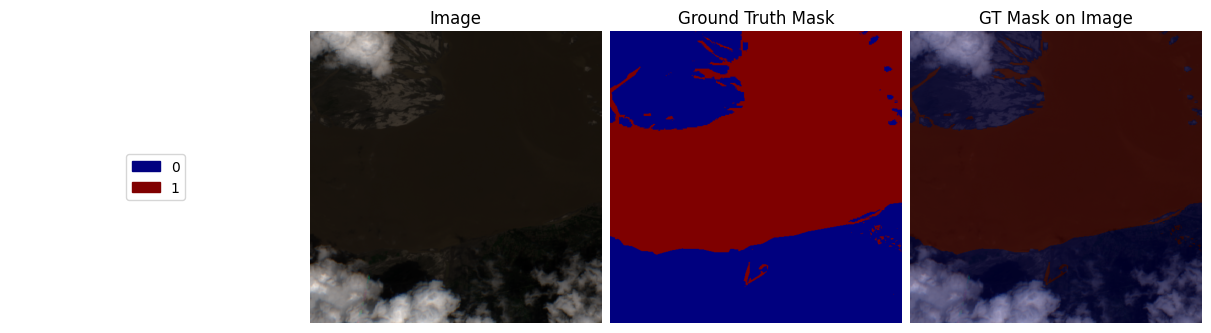

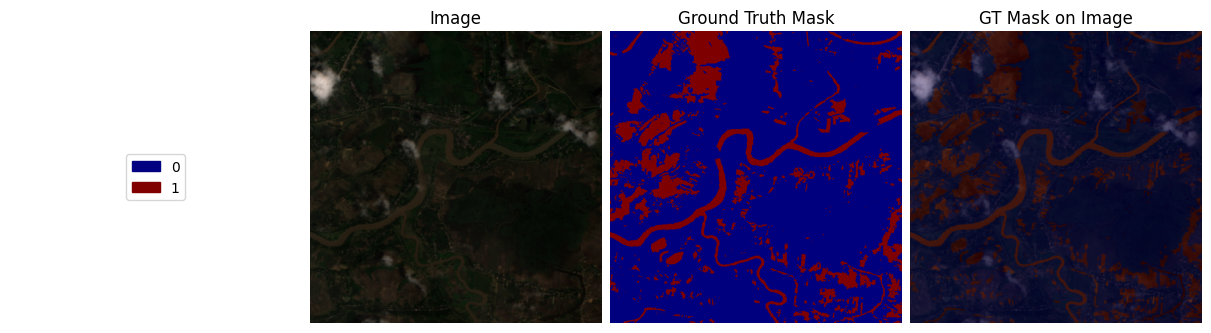

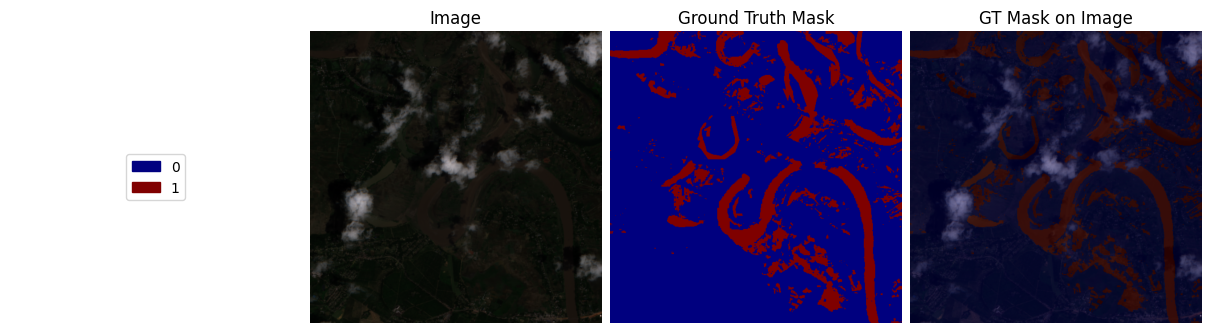

In [4]:
for i in range(10,14):
    _ = val_dataset.plot(val_dataset[i])

In [5]:
logger = logging.getLogger(__name__)

BACKBONE_SIZES = {"tiny", "small", "base", "large"}
BACKBONE_NECK_INDICES = {
    "tiny": [1, 3, 4, 5],
    "small": [1, 3, 4, 5],
    "base": [2, 5, 8, 11],
    "large": [5, 11, 17, 23],
}

backbone_size = "tiny"
backbone_name = f"terramind_v1_{backbone_size}"
neck_indices = BACKBONE_NECK_INDICES[backbone_size]

model_args = {
    "backbone": backbone_name,
    "backbone_pretrained": True,
    "backbone_modalities": ["S2L1C"],
    "backbone_bands": {"S2L1C": S2_BANDS},
    # Necks
    "necks": [
        {"name": "SelectIndices", "indices": neck_indices},
        {"name": "ReshapeTokensToImage", "remove_cls_token": False},
        {"name": "LearnedInterpolateToPyramidal"},
    ],
    # Decoder
    "decoder": "UNetDecoder",
    "decoder_channels": [256, 128, 64, 32],
    # Head
    "head_dropout": 0.1,
    "num_classes": 2,
}

task = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args=model_args,
    lr=2e-5,
    ignore_index=-1,
    plot_on_val=False,
    loss="ce",
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    class_names=["background", "flood"],
    freeze_backbone=True,
)   

2026-05-13 15:01:39,634 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"
2026-05-13 15:01:39,636 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


In [6]:
experiment_name = f"terramind_v1_{backbone_size}"
output_dir="/shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods"
logger = WandbLogger(project="terra-sat-drift", name=experiment_name, save_dir=root_dir)

checkpoint_callback = ModelCheckpoint(
    dirpath=output_dir + f"/{experiment_name}/checkpoints",
    filename="best-val_mIoU",
    monitor="val/mIoU",
    mode="max",
    save_top_k=3,
    verbose=True,
)

early_stopping = EarlyStopping(
    monitor="val/mIoU",
    patience=10,
    mode="max",
    verbose=True,
)

trainer = Trainer(
    max_epochs=50,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [7]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)

datamodule.setup(stage="fit")
trainer.fit(model=task, datamodule=datamodule)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /shared/home/elucas/.netrc.
wandb: Currently logged in as: elouannlucas56 (elouannlucas56-universit-bretagne-sud) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/shared/home/elucas/terra-sat-drift/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods/terramind_v1_tiny/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  8.0 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 5.7 M                                                                                        
Total params: 8.0 M                                                                                                
Total estimated model params size (MB): 32                                                                         
Modules in train mode: 288                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Epoch 37, global step 1178: 'val/mIoU' was not in top 3


Epoch 38, global step 1209: 'val/mIoU' reached 0.77757 (best 0.78137), saving model to '/shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods/terramind_v1_tiny/checkpoints/best-val_mIoU-v14.ckpt' as top 3


Epoch 39, global step 1240: 'val/mIoU' was not in top 3


Epoch 40, global step 1271: 'val/mIoU' was not in top 3


Monitored metric val/mIoU did not improve in the last 10 records. Best score: 0.781. Signaling Trainer to stop.
Epoch 41, global step 1302: 'val/mIoU' was not in top 3


In [8]:
trainer.test(model=task, dataloaders=datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/shared/home/elucas/terra-sat-drift/.venv/lib/python3.11/site-packages/terratorch/models/backbones/terramind/model/
terramind_vit.py:229: UserWarning: Unknown input modality: temporal_coords. Ignoring input.
  warnings.warn(f"Unknown input modality: {mod}. Ignoring input.")

/shared/home/elucas/terra-sat-drift/.venv/lib/python3.11/site-packages/terratorch/models/backbones/terramind/model/
terramind_vit.py:229: UserWarning: Unknown input modality: location_coords. Ignoring input.
  warnings.warn(f"Unknown input modality: {mod}. Ignoring input.")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Test metric           ┃          DataLoader 0          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/Accuracy          │       0.8722606301307678       │
│       test/Boundary_mIoU       │      0.08754515647888184       │
│ test/Class_Accuracy_background │       0.982136607170105        │
│   test/Class_Accuracy_flood    │       0.7623846530914307       │
│         test/F1_Score          │       0.8910907506942749       │
│      test/IoU_background       │       0.9498725533485413       │
│         test/IoU_flood         │       0.6776970028877258       │
│      test/Pixel_Accuracy       │       0.9546522498130798       │
│           test/loss            │      0.21905161440372467       │
│           test/mIoU            │       0.8137847781181335       │
│        test/mIoU_Micro         │       0.9132389426231384       │
└────────────────────────────────┴────────────────────────────────┘

[{'test/loss': 0.21905161440372467,
  'test/Accuracy': 0.8722606301307678,
  'test/Boundary_mIoU': 0.08754515647888184,
  'test/Class_Accuracy_background': 0.982136607170105,
  'test/Class_Accuracy_flood': 0.7623846530914307,
  'test/F1_Score': 0.8910907506942749,
  'test/IoU_background': 0.9498725533485413,
  'test/IoU_flood': 0.6776970028877258,
  'test/Pixel_Accuracy': 0.9546522498130798,
  'test/mIoU': 0.8137847781181335,
  'test/mIoU_Micro': 0.9132389426231384}]

## 3. Prepare Sample Data and Create RGB Composites

In [17]:
task.eval()

datamodule.setup("test")

test_loader = datamodule.test_dataloader()
test_dataset = datamodule.test_dataset

print(f"Available samples in the test dataset: {len(test_dataset)}")

Available samples in the test dataset: 90


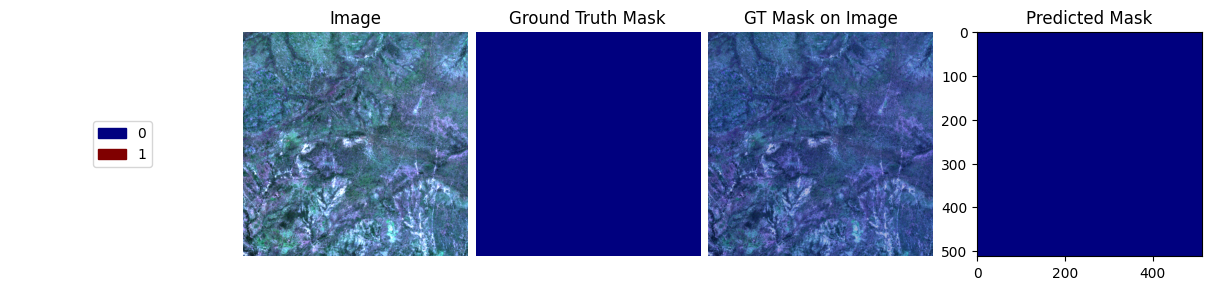

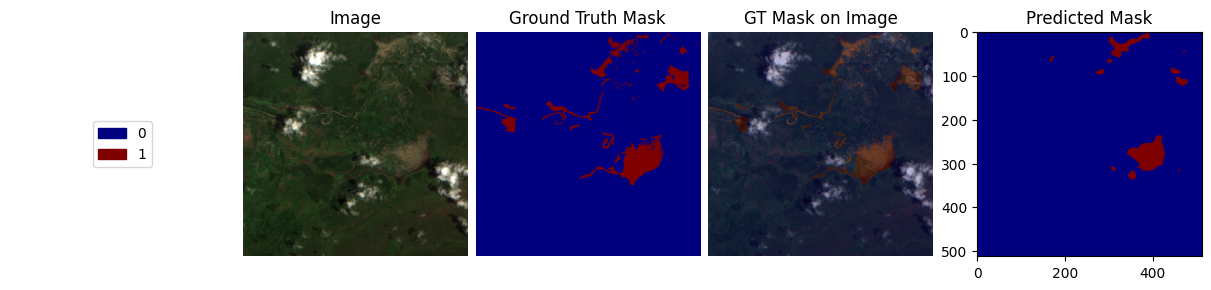

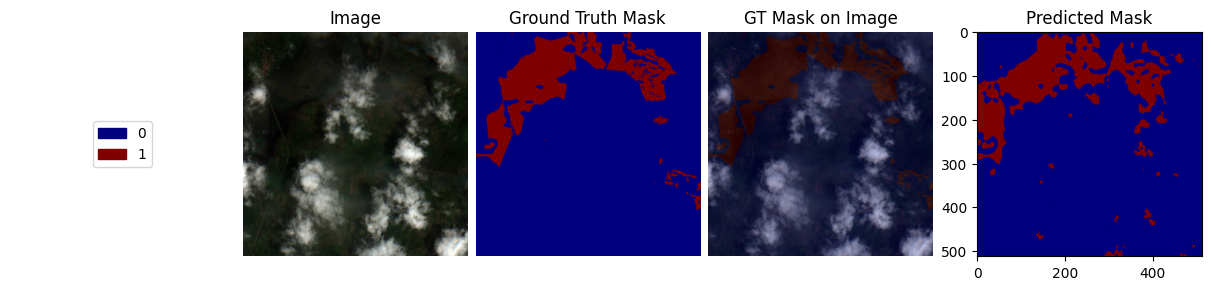

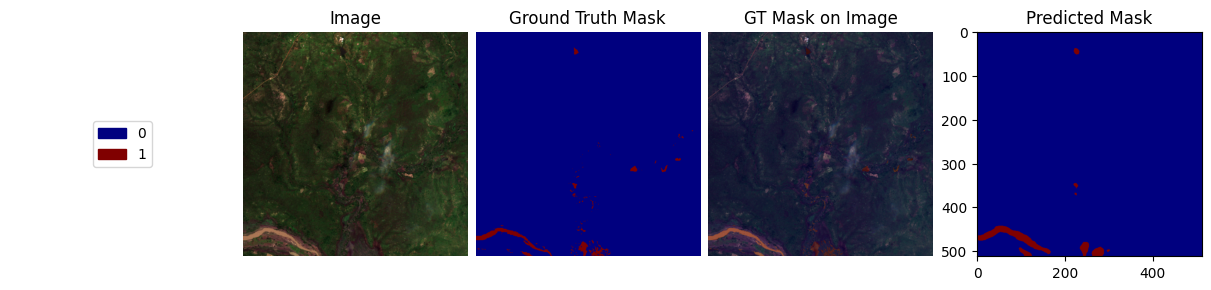

In [18]:
with torch.no_grad():
    batch = next(iter(test_loader))
    # Apply the same normalization used during training
    batch = datamodule.aug(batch)
    images = batch["image"].to(task.device)
    masks = batch["mask"].cpu().numpy()

    outputs = task(images)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

# Visualize a few predictions
num_examples = min(6, len(preds))
for i in range(2, num_examples):
    sample = {
        "image": batch["image"][i].cpu(),
        "mask": batch["mask"][i].squeeze().cpu(),
        "prediction": preds[i],
    }
    test_dataset.plot(sample)